<a href="https://colab.research.google.com/github/GowthamPitla/smart-audio-text-accuracy/blob/main/SHL_intern_assign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Import Libraries


In [1]:
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 2: Paths

In [3]:
# Paths
base_path = "/content/drive/MyDrive/SHL1203/ grammar-scoring"
audio_train_path = os.path.join(base_path, "/content/drive/MyDrive/SHL1203/ grammar-scoring/audio_folder/audios_train")
audio_test_path = os.path.join(base_path, "/content/drive/MyDrive/SHL1203/ grammar-scoring/audio_folder/audios_test")


### Step 3: Load CSV Files


In [4]:
# Load CSV files
train_df = pd.read_csv(os.path.join(base_path, "/content/drive/MyDrive/SHL1203/ grammar-scoring/train.csv"))
test_df = pd.read_csv(os.path.join(base_path, "/content/drive/MyDrive/SHL1203/ grammar-scoring/test.csv"))
sample_submission = pd.read_csv(os.path.join(base_path, "/content/drive/MyDrive/SHL1203/ grammar-scoring/sample_submission.csv"))

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (444, 2)
Test shape: (195, 1)


### Step 4: Function to extract MFCC features

In [5]:
# Function to extract MFCC features
def extract_features(file_path, n_mfcc=40):
    y, sr = librosa.load(file_path, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfccs.T, axis=0)

### Step 5: Extract features from train audio

In [6]:
# Extract features from train audio
train_features = []
for fname in train_df['filename']:
    path = os.path.join(audio_train_path, fname)
    features = extract_features(path)
    train_features.append(features)

X = np.array(train_features)
y = train_df['label'].values

# Extract features from test audio
test_features = []
for fname in test_df['filename']:
    path = os.path.join(audio_test_path, fname)
    features = extract_features(path)
    test_features.append(features)

X_test = np.array(test_features)

# Split for evaluation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
val_preds = model.predict(X_val)

### Step 6: Evaluation

In [7]:
# Evaluation
mse = mean_squared_error(y_val, val_preds)
r2 = r2_score(y_val, val_preds)
pearson_corr, _ = pearsonr(y_val, val_preds)

print(f"Validation MSE: {mse:.4f}")
print(f"Validation R2: {r2:.4f}")
print(f"Validation Pearson Correlation: {pearson_corr:.4f}")

Validation MSE: 1.1050
Validation R2: 0.1894
Validation Pearson Correlation: 0.4501


### Step 7: Convert predictions to grades for accuracy

In [8]:
def score_to_grade(score):
    if score >= 4.25:
        return 'A'
    elif score >= 3.5:
        return 'B'
    elif score >= 2.5:
        return 'C'
    elif score >= 1.5:
        return 'D'
    else:
        return 'E'

val_true_grades = [score_to_grade(v) for v in y_val]
val_pred_grades = [score_to_grade(v) for v in val_preds]
model_accuracy = accuracy_score(val_true_grades, val_pred_grades) * 100

print(f"Model Accuracy: {model_accuracy:.2f}%")

# Grammar score in percentage (based on R2 as proxy for now)
grammar_score_pct = r2 * 100
print(f"Grammar Score: {grammar_score_pct:.2f}%")

# Final prediction
test_preds = model.predict(X_test)

# Create submission
submission = pd.DataFrame({
    'filename': test_df['filename'],
    'label': test_preds
})

submission.to_csv("submission.csv", index=False)
print("✅ Submission saved as submission.csv")


Model Accuracy: 35.96%
Grammar Score: 18.94%
✅ Submission saved as submission.csv


### Step 8: Visualization

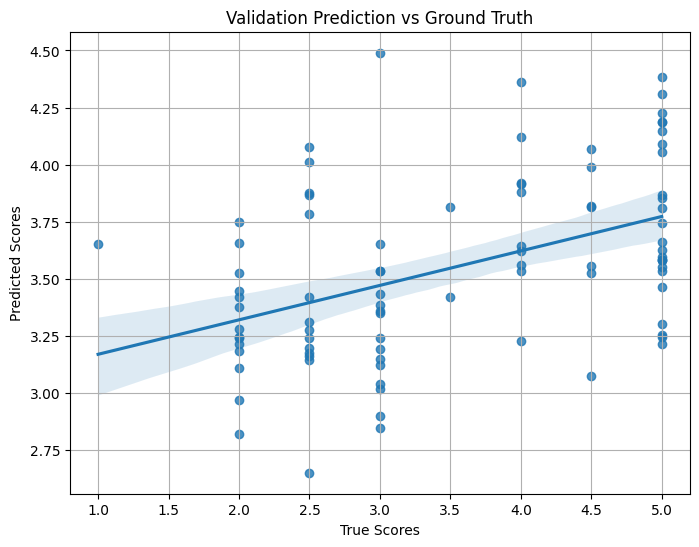

In [9]:
# Visualization
plt.figure(figsize=(8, 6))
sns.regplot(x=y_val, y=val_preds)
plt.xlabel("True Scores")
plt.ylabel("Predicted Scores")
plt.title("Validation Prediction vs Ground Truth")
plt.grid(True)
plt.show()